In [2]:
# Import necessary libraries
import re
import asyncio
import aiohttp
from bs4 import BeautifulSoup
from pydantic import BaseModel
from typing import List, Dict
import nest_asyncio
import json
import datetime

# Apply nest_asyncio to allow running asyncio in notebook
nest_asyncio.apply()

# Request headers for all requests
req_headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/123.0.0.0 Safari/537.36',
    'Accept-Language': 'en-US, en;q=0.5'
}

# Precompiled regex pattern for seller info (for efficiency)
SELLER_INFO_REGEX = r'^(.*?)\s*\(([\d,]+)\)\s*([\d.]+%)$'

print("Setup complete!")

Setup complete!


In [3]:
def get_title(soup):
    try:
        title_tag = soup.find("h1", id="itemTitle")
        if title_tag:
            return title_tag.get_text(strip=True).replace("Details about  \xa0", "")
    except Exception:
        pass
    return ""

def get_price(soup):
    try:
        price_tag = soup.find("span", id="prcIsum")
        if not price_tag:
            price_tag = soup.find("span", id="mm-saleDscPrc")
        if price_tag:
            return price_tag.get_text(strip=True)
    except Exception:
        pass
    return ""

def get_images(soup):
    buttons = soup.find_all("button", class_="ux-image-grid-item image-treatment rounded-edges")
    images = []
    for btn in buttons:
        img = btn.find('img')
        if img and img.get('src'):
            images.append(img.get('src'))
    return images

def get_watchers(soup):
    try:
        divs = soup.find_all("div", class_="ux-section-icon-with-details__data-item-text")
        if divs:
            text = divs[0].text.strip()
            numbers = re.findall(r'\d+', text)
            return numbers[0] if numbers else ""
    except Exception:
        pass
    return ""

def get_condition(soup):
    try:
        condition_div = soup.find("div", class_='x-item-condition-text')
        if condition_div:
            span = condition_div.find("span", class_="clipped")
            if span:
                return span.text.strip()
    except Exception:
        pass
    return ""

def get_item_features(soup):
    features = {}
    try:
        container = soup.find("div", id="viTabs_0_is")
        if container:
            container = container.find("div", class_="ux-layout-section-evo__item ux-layout-section-evo__item--table-view")
            if container:
                rows = container.find_all("div", class_="ux-layout-section-evo__row")
                for row in rows:
                    dls = row.find_all("dl")
                    for dl in dls:
                        dt = dl.find("dt")
                        dd = dl.find("dd")
                        if dt and dd:
                            label = dt.get_text(strip=True)
                            value_container = dd.find("div", class_="ux-labels-values__values-content")
                            value = value_container.get_text(strip=True) if value_container else dd.get_text(strip=True)
                            features[label] = value
    except Exception:
        pass
    return features

print("Product detail extraction functions loaded!")

Product detail extraction functions loaded!


In [4]:
def auction_get_title(item):
    try:
        return item.find("div", class_="s-item__title").text.strip()
    except Exception:
        return ""

def auction_get_price(item):
    try:
        return item.find("span", class_="s-item__price").text.strip()
    except Exception:
        return ""

def auction_get_bid_count(item):
    try:
        bid_elem = item.select_one("span.s-item__bids.s-item__bidCount")
        return bid_elem.text.strip() if bid_elem else ""
    except Exception:
        return ""

def auction_get_time_left(item):
    try:
        return item.find("span", class_="s-item__time-left").text.strip()
    except Exception:
        return ""

def auction_get_best_offer(item):
    try:
        bo_elem = item.select_one("div.s-item__dynamic.s-item__formatBestOfferEnabled a span")
        return bo_elem.text.strip() if bo_elem else ""
    except Exception:
        return ""

def auction_get_delivery_cost(item):
    try:
        delivery_elem = item.select_one("span.s-item__shipping.s-item__logisticsCost")
        return delivery_elem.text.strip() if delivery_elem else ""
    except Exception:
        return ""

def auction_get_authenticity(item):
    try:
        auth_elem = item.select_one("span.s-item__hotness.s-item__authorized-seller")
        return auth_elem.text.strip() if auth_elem else ""
    except Exception:
        return ""

def auction_get_product_image(item):
    try:
        image_wrapper = item.find("div", class_="s-item__image-wrapper image-treatment")
        if image_wrapper:
            img = image_wrapper.find("img")
            return img['src'].strip() if img and img.get('src') else ""
    except Exception:
        return ""
    return ""

def auction_get_product_link(item):
    try:
        a_tag = item.find("a", href=True)
        return a_tag['href'].strip() if a_tag else ""
    except Exception:
        return ""

def auction_get_seller_info(item):
    try:
        seller_info = item.find("span", class_="s-item__seller-info-text").text.strip()
    except AttributeError:
        seller_info = ""
    return seller_info

def parse_seller_info(seller_info):
    """
    Uses a precompiled regex for efficiency.
    Expected format: "seller_name (number) rating"
    """
    match = re.search(SELLER_INFO_REGEX, seller_info)
    if match:
        seller_name = match.group(1).strip()
        seller_no_reviews = match.group(2).replace(',', '')
        seller_rating = match.group(3)
        return seller_name, seller_no_reviews, seller_rating
    return seller_info, "", ""

print("Auction listing extraction functions loaded!")

Auction listing extraction functions loaded!


In [5]:
async def fetch_page(session: aiohttp.ClientSession, url: str, headers: dict) -> str:
    async with session.get(url, headers=headers, timeout=10) as response:
        if response.status != 200:
            raise Exception(f"Error fetching {url}: Status code {response.status}")
        return await response.text()

print("Async fetch function loaded!")

Async fetch function loaded!


In [6]:
async def search_auctions(search_term: str = "iphone", pages: int = 1):
    """
    Asynchronously search eBay auctions for a given search term across the specified number of pages.
    Returns detailed auction data concurrently.
    """
    tasks = []
    async with aiohttp.ClientSession() as session:
        for page in range(1, pages + 1):
            search_url = f'https://www.ebay.com/sch/i.html?_nkw={search_term}&LH_Auction=1&_pgn={page}'
            tasks.append(fetch_page(session, search_url, req_headers))
        pages_content = await asyncio.gather(*tasks)
    
    auctions = []
    for content in pages_content:
        # Parse the HTML content
        soup = BeautifulSoup(content, "html.parser")
        items = soup.find_all("li", class_="s-item s-item__pl-on-bottom")
        for item in items:
            title = auction_get_title(item)
            if not title or title == "Shop on eBay":
                continue
            price = auction_get_price(item)
            product_link = auction_get_product_link(item)
            bid_count = auction_get_bid_count(item)
            time_left = auction_get_time_left(item)
            best_offer = auction_get_best_offer(item)
            delivery_cost = auction_get_delivery_cost(item)
            authenticity = auction_get_authenticity(item)
            product_image = auction_get_product_image(item)
            seller_info_raw = auction_get_seller_info(item)
            seller_name, seller_no_reviews, seller_rating = parse_seller_info(seller_info_raw)
            
            auctions.append({
                "title": title,
                "price": price,
                "product_link": product_link,
                "bid_count": bid_count,
                "time_left": time_left,
                "best_offer": best_offer,
                "delivery_cost": delivery_cost,
                "authenticity": authenticity,
                "product_image": product_image,
                "seller_info": seller_info_raw,
                "seller_name": seller_name,
                "seller_no_reviews": seller_no_reviews,
                "seller_rating": seller_rating
            })
    
    return auctions

print("Search auctions function loaded!")

Search auctions function loaded!


In [7]:
async def fetch_product_data(url: str, headers: dict = req_headers) -> dict:
    try:
        async with aiohttp.ClientSession() as session:
            async with session.get(url, headers=headers, timeout=10) as response:
                if response.status != 200:
                    return {"product_link": url, "error": f"Status code {response.status}"}
                html = await response.text()
                # Parse the content
                soup = BeautifulSoup(html, "html.parser")
                return {
                    "title": get_title(soup),
                    "price": get_price(soup),
                    "images": get_images(soup),
                    "watchers": get_watchers(soup),
                    "condition": get_condition(soup),
                    "item_features": get_item_features(soup),
                    "product_link": url
                }
    except Exception as e:
        return {"product_link": url, "error": str(e)}

print("Product data fetch function loaded!")

Product data fetch function loaded!


In [19]:
async def run_sample_search():
    results = await search_auctions("sony 24-70 gm ii", pages=10)
    print(f"Found {len(results)} auctions")
    
    # Display first 3 results
    for i, result in enumerate(results[:3], 1):
        print(f"\nResult {i}:")
        print(f"Title: {result['title']}")
        print(f"Price: {result['price']}")
        print(f"Bids: {result['bid_count']}")
        print(f"Time left: {result['time_left']}")
        print(f"Seller: {result['seller_name']}")
        print(f"Link: {result['product_link']}")
    
    return results

# Execute the search
search_results = await run_sample_search()

Found 23 auctions

Result 1:
Title: Sony FE 70-200mm F/2.8 GM OSS II Lens SEL70200GM2
Price: $1,955.00
Bids: 10 bids ·
Time left: 2h 48m left
Seller: estatenet
Link: https://www.ebay.com/itm/226633440507?_skw=sony+24-70+gm+ii&itmmeta=01JPG45Y6NH4TKRN67BACKNKVZ&hash=item34c467dcfb%3Ag%3AxP0AAeSwbbxnygJJ&itmprp=enc%3AAQAKAAAA8FkggFvd1GGDu0w3yXCmi1cziHsXZJt--Nx8AoHp2v9wyQmE%2BUFCtl%2BptOwmeXMLX08KR%2FKW3Q4EoCeVlJ0CRPXIThgqk5dhHK6klrsb1g803m49BJ8C%2B5c5pK5Zgy2bfEJF9RH2foyXjn3QznfzGhNZbXbm%2FCJbaLfbEdUdF0dk0bHLCsPglxpwCyuyzSfwBZH%2Fj3agP2ILXyM%2FyoyE09KKk3KDOThyL9utSSG02OEK0lNOmuPpUftGN4daH1A2juIR0SdSIORH66t%2BIPNFaEBA%2F%2BMSmdD%2F0EBEFb0lI44UptJYSVszlxrGArWtMo6eBA%3D%3D%7Ctkp%3ABk9SR5Dkl4S0ZQ&LH_Auction=1

Result 2:
Title: Sony G Master FE 24-70 mm F2.8 GM Full-Frame E-Mount Standard Zoom Lens USED
Price: $895.00
Bids: 0 bids ·
Time left: 1d 10h left
Seller: treasurehunt143
Link: https://www.ebay.com/itm/256852363297?_skw=sony+24-70+gm+ii&itmmeta=01JPG45Y6N27H6WHDHRASZCKBR&hash=item3bcd98

In [20]:
async def get_product_details():
    # Use the first product link from our search results
    if not search_results or len(search_results) == 0:
        print("No search results available. Run the search first.")
        return
    
    product_link = search_results[0]['product_link']
    print(f"Fetching details for: {search_results[0]['title']}")
    
    details = await fetch_product_data(product_link)
    
    print("\nProduct Details:")
    print(f"Title: {details.get('title', 'N/A')}")
    print(f"Price: {details.get('price', 'N/A')}")
    print(f"Condition: {details.get('condition', 'N/A')}")
    print(f"Watchers: {details.get('watchers', 'N/A')}")
    print(f"Number of images: {len(details.get('images', []))}")
    
    print("\nFeatures:")
    for key, value in details.get('item_features', {}).items():
        print(f"- {key}: {value}")
    
    return details

# Execute to get product details
product_details = await get_product_details()

Fetching details for: Sony FE 70-200mm F/2.8 GM OSS II Lens SEL70200GM2

Product Details:
Title: 
Price: 
Condition: Used
Watchers: 43
Number of images: 5

Features:
- Condition: Used: An item that has been used previously. The item may have some signs of cosmetic wear, but is ...Read moreabout the conditionUsed: An item that has been used previously. The item may have some signs of cosmetic wear, but is fully operational and functions as intended. This item may be a floor model or store return that has been used. See the seller’s listing for full details and description of any imperfections.See all condition definitionsopens in a new window or tab
- Brand: Sony
- Focal Length: 70-200mm
- Maximum Aperture: f/2.8
- Series: Sony FE
- Type: Lens
- Focus Type: Manual
- Mount: Sony E-mount


In [21]:
async def find_highest_bid_count_auctions(search_term="sony 24-70 gm", pages=2):
    results = await search_auctions(search_term, pages)
    
    # Filter out items with no bid count
    items_with_bids = []
    for item in results:
        if item['bid_count']:
            try:
                # Extract number from bid text (e.g., "5 bids" -> 5)
                bid_count = int(re.search(r'\d+', item['bid_count']).group())
                item['bid_count_num'] = bid_count
                items_with_bids.append(item)
            except (AttributeError, ValueError):
                continue
    
    # Sort by bid count (highest first)
    sorted_items = sorted(items_with_bids, key=lambda x: x['time_left'], reverse=False)
    
    print(f"\nTop 5 Most Popular {search_term} Auctions (by bid count):")
    for i, item in enumerate(sorted_items[:10], 1):
        print(f"{i}. {item['title']} - {item['price']} - {item['bid_count']} - {item['time_left']}")
    
    return sorted_items

# Execute to find popular auctions
popular_auctions = await find_highest_bid_count_auctions("sony 24-70 gm")


Top 5 Most Popular sony 24-70 gm Auctions (by bid count):
1. Sony G Master FE 24-70 mm F2.8 GM Full-Frame E-Mount Standard Zoom Lens USED - $895.00 - 0 bids · - 1d 10h left
2. Sony G Master FE 24-70 mm F2.8 GM Full-Frame E-Mount Standard Zoom Lens USED - $895.00 - 0 bids · - 1d 10h left
3. Sigma 24-70mm f/2.8 DG DN Art Zoom Lens for Sony E Mount Mirrorless Cameras - $605.00 - 2 bids · - 2d 1h left
4. Sigma 24-70mm f/2.8 DG DN Art Zoom Lens for Sony E Mount Mirrorless Cameras - $605.00 - 2 bids · - 2d 1h left
5. Box - $50.00 - 0 bids · - 2d 23h left
6. Box - $50.00 - 0 bids · - 2d 23h left
7. Sony FE 24mm f/1.4 GM Camera Lens - Black (SEL24F14GM) - $315.00 - 15 bids · - 2d 4h left
8. Sony FE 24mm f/1.4 GM Camera Lens - Black (SEL24F14GM) - $315.00 - 15 bids · - 2d 4h left
9. Sony FE 70-200mm F/2.8 GM OSS II Lens SEL70200GM2 - $1,955.00 - 10 bids · - 2h 48m left
10. Sony FE 70-200mm F/2.8 GM OSS II Lens SEL70200GM2 - $1,955.00 - 10 bids · - 2h 48m left


In [22]:
def save_to_json(data, filename="ebay_results.json"):
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"Data saved to {filename}")

# Save our search results
save_to_json(search_results, "vintage_watches.json")

Data saved to vintage_watches.json


# Detecting price-inflating buzzwords in descriptions

Top 10 Price-Inflating Buzzwords: ['200mm' '70' 'f2' 'hood' 'gm' 'fe' 'ii' 'camera' 'ultrasonic' 'ef']


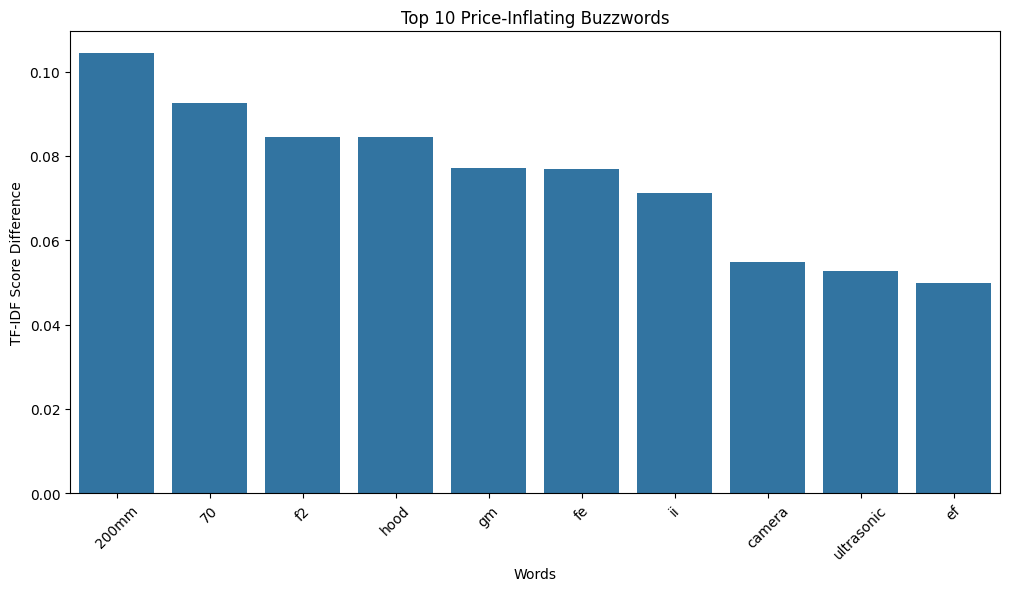

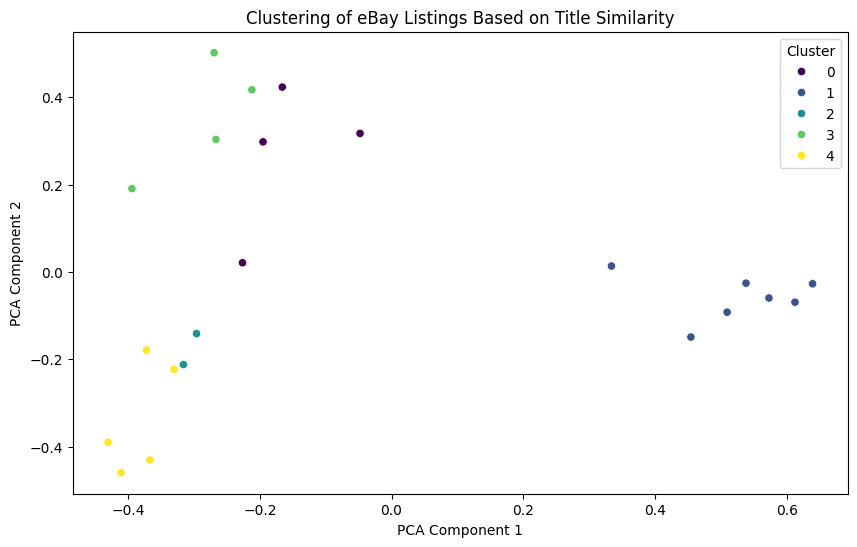

In [38]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Example: Process scraped eBay data
def process_ebay_data(search_results):
    data = []
    for item in search_results:
        title = item.get('title', '')
        price_str = item.get('price', '')
        
        # Convert price to float
        price_match = re.search(r'\d+[,.]?\d*', price_str)
        price = float(price_match.group().replace(',', '')) if price_match else None
        
        if title and price is not None:
            data.append((title, price))
    
    return pd.DataFrame(data, columns=['title', 'price'])

# Load scraped search results into DataFrame
df = process_ebay_data(search_results)

# Define price thresholds (e.g., median split)
median_price = df['price'].median()
high_price_indices = np.where(df['price'] > median_price)[0]
low_price_indices = np.where(df['price'] <= median_price)[0]

# Compute TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)

# Fit on product titles
tfidf_matrix = vectorizer.fit_transform(df['title'])
feature_names = np.array(vectorizer.get_feature_names_out())

# Compute average TF-IDF score for high and low price groups
high_price_tfidf = tfidf_matrix[high_price_indices].mean(axis=0).A1
low_price_tfidf = tfidf_matrix[low_price_indices].mean(axis=0).A1

# Find words with the largest difference in TF-IDF scores
score_diff = high_price_tfidf - low_price_tfidf
sorted_indices = np.argsort(-score_diff)
buzzwords = feature_names[sorted_indices][:10]  # Top 10 price-inflating words

print("Top 10 Price-Inflating Buzzwords:", buzzwords)

# Visualization: TF-IDF score comparison
plt.figure(figsize=(12, 6))
sns.barplot(x=buzzwords, y=score_diff[sorted_indices][:10])
plt.xlabel("Words")
plt.ylabel("TF-IDF Score Difference")
plt.title("Top 10 Price-Inflating Buzzwords")
plt.xticks(rotation=45)
plt.show()

# Clustering similar product titles using K-Means
num_clusters = 5  # Adjust cluster size as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_

# PCA for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())
df['pca_x'] = reduced_features[:, 0]
df['pca_y'] = reduced_features[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['pca_x'], y=df['pca_y'], hue=df['cluster'], palette='viridis')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clustering of eBay Listings Based on Title Similarity")
plt.legend(title="Cluster")
plt.show()


# Detecting Spam keywords for keyword stuffing

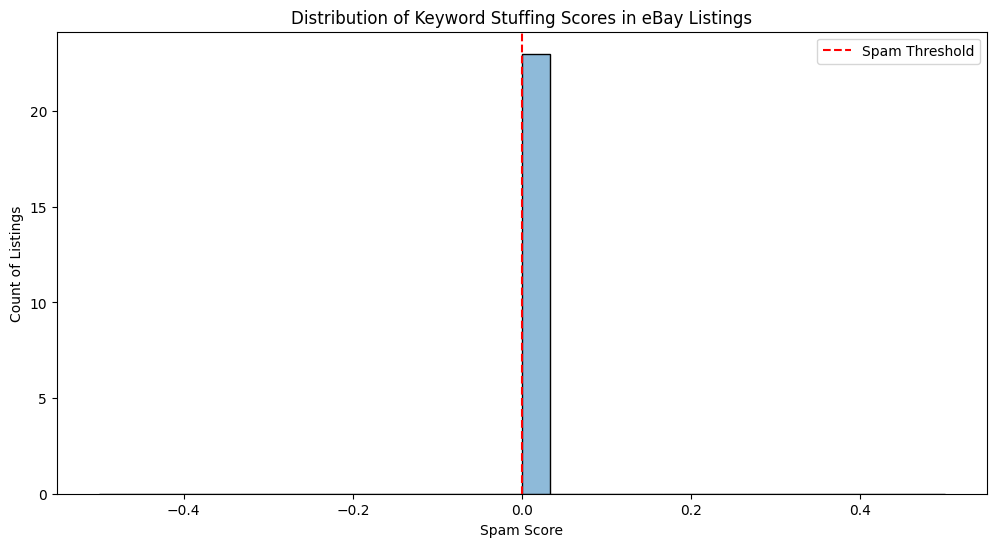

Top Spammy Listings:
Empty DataFrame
Columns: [title, price, spam_score]
Index: []


In [36]:
def process_ebay_data(search_results):
    data = []
    for item in search_results:
        title = item.get('title', '')
        price_str = item.get('price', '')
        
        # Convert price to float
        price_match = re.search(r'\d+[,.]?\d*', price_str)
        price = float(price_match.group().replace(',', '')) if price_match else None
        
        if title and price is not None:
            data.append((title, price))
    
    return pd.DataFrame(data, columns=['title', 'price'])

# Load scraped search results into DataFrame
df = process_ebay_data(search_results)

# Compute TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(df['title'])
feature_names = np.array(vectorizer.get_feature_names_out())

# Define common high-traffic keywords used for keyword stuffing
spam_keywords = ["nike", "adidas", "yeezy", "jordan", "supreme", "rare", "limited", "exclusive"]

# Identify spammy listings
spam_scores = np.zeros(len(df))
for keyword in spam_keywords:
    if keyword in feature_names:
        keyword_index = np.where(feature_names == keyword)[0][0]
        spam_scores += tfidf_matrix[:, keyword_index].toarray().flatten()

df['spam_score'] = spam_scores

# Define threshold for spam detection (e.g., top 10% most keyword-stuffed listings)
threshold = np.percentile(spam_scores, 90)
df['is_spam'] = df['spam_score'] > threshold

# Visualization: Distribution of spam scores
plt.figure(figsize=(12, 6))
sns.histplot(df['spam_score'], bins=30, kde=True)
plt.axvline(threshold, color='red', linestyle='dashed', label='Spam Threshold')
plt.xlabel("Spam Score")
plt.ylabel("Count of Listings")
plt.title("Distribution of Keyword Stuffing Scores in eBay Listings")
plt.legend()
plt.show()

# Print top spammy listings
spammy_listings = df[df['is_spam']]
print("Top Spammy Listings:")
print(spammy_listings[['title', 'price', 'spam_score']].sort_values(by='spam_score', ascending=False).head(10))


In [ ]:
# Example: Process scraped eBay data
def process_ebay_data(search_results):
    data = []
    for item in search_results:
        title = item.get('title', '')
        price_str = item.get('price', '')
        
        # Convert price to float
        price_match = re.search(r'\d+[,.]?\d*', price_str)
        price = float(price_match.group().replace(',', '')) if price_match else None
        
        if title and price is not None:
            data.append((title, price))
    
    return pd.DataFrame(data, columns=['title', 'price'])

# Load scraped search results into DataFrames
df = process_ebay_data(search_results)

# Compute TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
tfidf_matrix = vectorizer.fit_transform(df['title'])

# Compute cosine similarity between all listings
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

# Identify duplicate or near-duplicate listings (high cosine similarity)
threshold = 0.85  # Similarity threshold for detecting plagiarism
similar_pairs = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if cosine_sim_matrix[i, j] > threshold:
            similar_pairs.append((df.iloc[i]['title'], df.iloc[j]['title'], cosine_sim_matrix[i, j]))

# Convert to DataFrame for analysis
similar_df = pd.DataFrame(similar_pairs, columns=['Listing 1', 'Listing 2', 'Similarity Score'])

# Visualization: Heatmap of similarity scores
plt.figure(figsize=(10, 6))
sns.heatmap(cosine_sim_matrix, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("Cosine Similarity Between eBay Listings")
plt.xlabel("Listing Index")
plt.ylabel("Listing Index")
plt.show()

# Print top similar listings
print("Top Plagiarized Listings:")
print(similar_df.sort_values(by='Similarity Score', ascending=False).head(10))
